In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
def generate_ct_volume(shape=(128, 256, 256)):
    """
    Generate a synthetic CT volume with realistic Hounsfield Units.
    shape = (slices, height, width)
    """
    volume = np.full(shape, -1000, dtype=np.float32)  # air background
    
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    cz, cy, cx = shape[0]//2, shape[1]//2, shape[2]//2
    
    # ── body outline (ellipsoid) ─────────────────────────────────────
    body = ((z-cz)/50)**2 + ((y-cy)/90)**2 + ((x-cx)/70)**2 < 1
    volume[body] = 50  # soft tissue ~50 HU
    
    # ── spine (central bone column) ──────────────────────────────────
    spine = ((y-cy)/8)**2 + ((x-cx)/8)**2 < 1
    volume[spine & body] = 700  # bone ~700 HU
    
    # ── ribs (curved bone structures) ────────────────────────────────
    for i, zpos in enumerate(range(30, 100, 10)):
        angle = i * 0.3
        for t in np.linspace(0, np.pi, 60):
            rx = int(cx + 55 * np.cos(t) * np.cos(angle))
            ry = int(cy + 55 * np.sin(t))
            rz = int(zpos + 5 * np.sin(t * 2))
            if 0 <= rx < shape[2] and 0 <= ry < shape[1] and 0 <= rz < shape[0]:
                volume[max(0,rz-2):rz+2,
                       max(0,ry-2):ry+2,
                       max(0,rx-2):rx+2] = 700

    # ── lungs (low density ellipsoids) ───────────────────────────────
    lung_l = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx-25))/25)**2 < 1
    lung_r = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx+25))/25)**2 < 1
    volume[lung_l & body] = -500  # lung ~-500 HU
    volume[lung_r & body] = -500

    # ── liver (right side, mid-abdomen) ──────────────────────────────
    liver = ((z-(cz+15))/25)**2 + ((y-(cy+15))/30)**2 + ((x-(cx+20))/28)**2 < 1
    volume[liver & body] = 60  # liver ~60 HU

    # ── kidneys ──────────────────────────────────────────────────────
    kidney_l = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx-30))/10)**2 < 1
    kidney_r = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx+30))/10)**2 < 1
    volume[kidney_l & body] = 30  # kidney ~30 HU
    volume[kidney_r & body] = 30

    # ── aorta (central vessel) ────────────────────────────────────────
    aorta = ((y-(cy+5))/6)**2 + ((x-(cx-8))/6)**2 < 1
    volume[aorta & body] = 40  # blood ~40 HU

    # add realistic noise
    noise = np.random.normal(0, 15, shape).astype(np.float32)
    volume += noise
    
    # smooth slightly
    volume = ndimage.gaussian_filter(volume, sigma=0.8)
    
    return volume

print("Generating synthetic CT volume...")
np.random.seed(42)
volume = generate_ct_volume(shape=(128, 256, 256))

print(f"Volume shape: {volume.shape}")
print(f"  Slices (Z): {volume.shape[0]}")
print(f"  Height (Y): {volume.shape[1]}")
print(f"  Width  (X): {volume.shape[2]}")
print(f"\nHounsfield Unit statistics:")
print(f"  Min:  {volume.min():.1f} HU")
print(f"  Max:  {volume.max():.1f} HU")
print(f"  Mean: {volume.mean():.1f} HU")
print(f"\nMemory usage: {volume.nbytes / 1024**2:.1f} MB")

Generating synthetic CT volume...
Volume shape: (128, 256, 256)
  Slices (Z): 128
  Height (Y): 256
  Width  (X): 256

Hounsfield Unit statistics:
  Min:  -1020.1 HU
  Max:  710.4 HU
  Mean: -849.9 HU

Memory usage: 32.0 MB


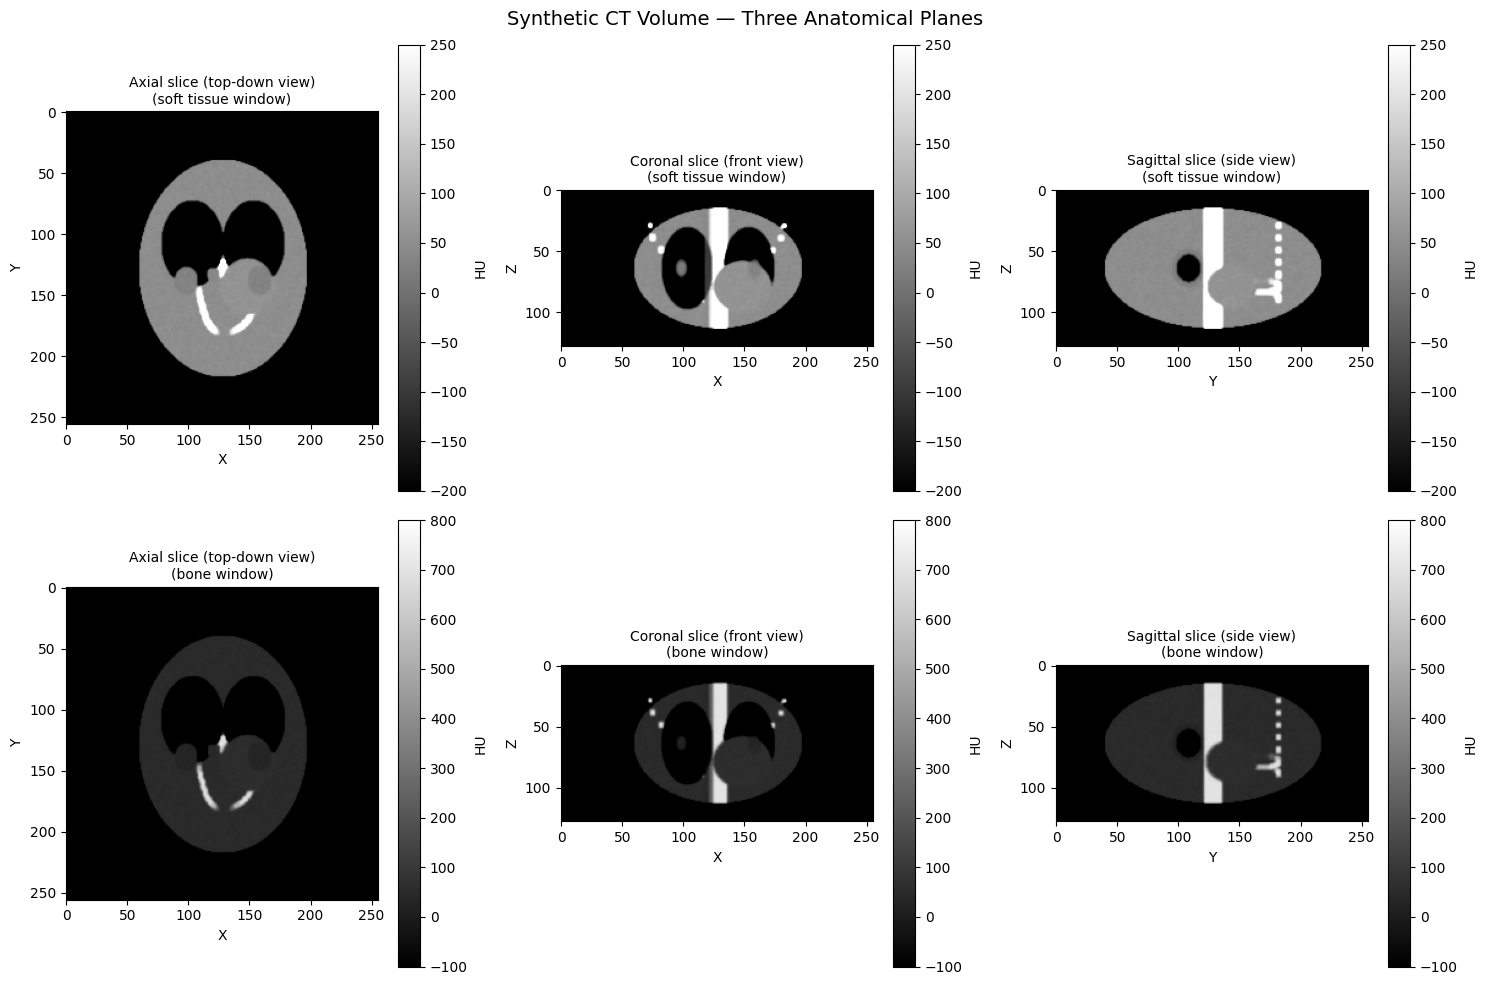

Saved to outputs/ct_slices.png


In [3]:
# three anatomical views — axial, coronal, sagittal
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

mid_z = volume.shape[0] // 2
mid_y = volume.shape[1] // 2
mid_x = volume.shape[2] // 2

views = [
    (volume[mid_z, :, :],   "Axial slice (top-down view)",      "X", "Y"),
    (volume[:, mid_y, :],   "Coronal slice (front view)",       "X", "Z"),
    (volume[:, :, mid_x],   "Sagittal slice (side view)",       "Y", "Z"),
]

# CT window presets
windows = [
    ("Soft tissue window\n(WL=50, WW=400)", 50-200, 50+200),
    ("Lung window\n(WL=-600, WW=1500)",    -600-750, -600+750),
    ("Bone window\n(WL=400, WW=1800)",      400-900, 400+900),
]

for col, (slice_data, title, xlabel, ylabel) in enumerate(views):
    for row, (win_title, vmin, vmax) in enumerate([(windows[0], windows[0][1], windows[0][2]),]):
        ax = axes[0, col]
        im = ax.imshow(slice_data, cmap='gray', vmin=-200, vmax=250,
                       aspect='equal', origin='upper')
        ax.set_title(f'{title}\n(soft tissue window)', fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.colorbar(im, ax=ax, label='HU')

# bone window views
for col, (slice_data, title, xlabel, ylabel) in enumerate(views):
    ax = axes[1, col]
    im = ax.imshow(slice_data, cmap='gray', vmin=-100, vmax=800,
                   aspect='equal', origin='upper')
    ax.set_title(f'{title}\n(bone window)', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax, label='HU')

plt.suptitle('Synthetic CT Volume — Three Anatomical Planes', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/ct_slices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/ct_slices.png")

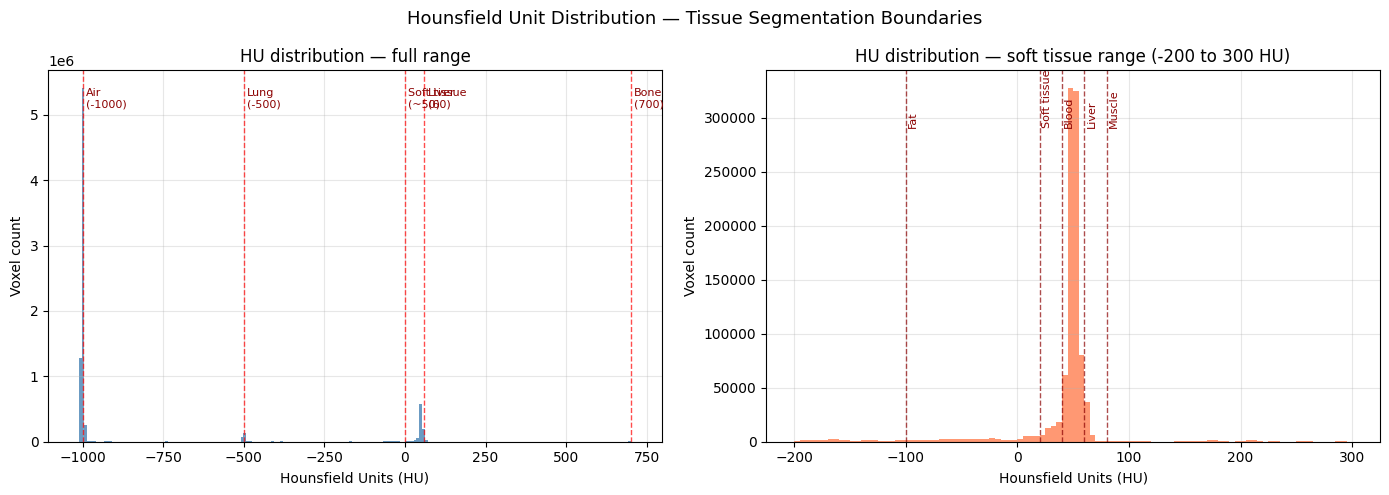

Saved to outputs/hu_distribution.png


In [4]:
# HU histogram — shows tissue density distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full range
axes[0].hist(volume.flatten(), bins=200, color='steelblue',
             edgecolor='none', alpha=0.8)
axes[0].set_title('HU distribution — full range')
axes[0].set_xlabel('Hounsfield Units (HU)')
axes[0].set_ylabel('Voxel count')
axes[0].grid(alpha=0.3)

# annotate tissue boundaries
tissue_ranges = [
    (-1000, 'Air\n(-1000)', '#87CEEB'),
    (-500,  'Lung\n(-500)', '#90EE90'),
    (0,     'Soft tissue\n(~50)', '#FFA07A'),
    (60,    'Liver\n(60)', '#DDA0DD'),
    (700,   'Bone\n(700)', '#F5F5DC'),
]
for hu, label, color in tissue_ranges:
    axes[0].axvline(x=hu, color='red', linestyle='--',
                    alpha=0.7, linewidth=1)
    axes[0].text(hu+10, axes[0].get_ylim()[1]*0.9,
                 label, fontsize=8, color='darkred')

# zoomed soft tissue range
mask = (volume.flatten() > -200) & (volume.flatten() < 300)
axes[1].hist(volume.flatten()[mask], bins=100,
             color='coral', edgecolor='none', alpha=0.8)
axes[1].set_title('HU distribution — soft tissue range (-200 to 300 HU)')
axes[1].set_xlabel('Hounsfield Units (HU)')
axes[1].set_ylabel('Voxel count')
axes[1].grid(alpha=0.3)

for hu, label, _ in [(-100,'Fat',-1),(20,'Soft tissue',-1),
                      (40,'Blood',-1),(60,'Liver',-1),(80,'Muscle',-1)]:
    axes[1].axvline(x=hu, color='darkred', linestyle='--',
                    alpha=0.7, linewidth=1)
    axes[1].text(hu+2, axes[1].get_ylim()[1]*0.85,
                 label, fontsize=8, color='darkred', rotation=90)

plt.suptitle('Hounsfield Unit Distribution — Tissue Segmentation Boundaries',
             fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/hu_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/hu_distribution.png")